In [115]:
#importing nwcessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
#loading the dataset
df=pd.read_csv(("../Dataset/customer_churn_prediction_dataset.csv")
)

In [98]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


In [118]:
#checking the no:of rows and columns of the dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 300 rows and 21 columns


In [119]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.000000,300.000000,300.000000,300.000000
mean,0.543333,35.783333,67.226800,2477.975767
std,0.498951,21.113400,28.638073,1918.540111
min,0.000000,1.000000,18.450000,30.030000
25%,0.000000,17.000000,42.337500,910.302500
50%,1.000000,36.000000,68.635000,2072.400000
75%,1.000000,53.250000,92.430000,3618.405000
max,1.000000,72.000000,118.640000,8318.880000


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    object 
 7   MultipleLines     300 non-null    object 
 8   InternetService   300 non-null    object 
 9   OnlineSecurity    300 non-null    object 
 10  OnlineBackup      300 non-null    object 
 11  DeviceProtection  300 non-null    object 
 12  TechSupport       300 non-null    object 
 13  StreamingTV       300 non-null    object 
 14  StreamingMovies   300 non-null    object 
 15  Contract          300 non-null    object 
 16  PaperlessBilling  300 non-null    object 
 1

Majority of the features in the datapoints is categorical




In [121]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There are no null values in the dataset

Categorical Feature Distribution Analysis

In [ ]:
cat_cols=[col for col in df.select_dtypes(include="object").columns if col !='customerID']
for col in cat_cols:
    print(df[col].value_counts(normalize=True))
    

gender
Male      0.503333
Female    0.496667
Name: proportion, dtype: float64
Partner
Yes    0.516667
No     0.483333
Name: proportion, dtype: float64
Dependents
Yes    0.526667
No     0.473333
Name: proportion, dtype: float64
PhoneService
Yes    0.52
No     0.48
Name: proportion, dtype: float64
MultipleLines
No                  0.350000
Yes                 0.333333
No phone service    0.316667
Name: proportion, dtype: float64
InternetService
Fiber optic    0.35
No             0.33
DSL            0.32
Name: proportion, dtype: float64
OnlineSecurity
No                     0.356667
Yes                    0.330000
No internet service    0.313333
Name: proportion, dtype: float64
OnlineBackup
No                     0.363333
Yes                    0.353333
No internet service    0.283333
Name: proportion, dtype: float64
DeviceProtection
Yes                    0.366667
No internet service    0.320000
No                     0.313333
Name: proportion, dtype: float64
TechSupport
No internet serv

The categorical features show well-distributed category proportions with no extreme skewness or rare categories, indicating sufficient representation across groups.

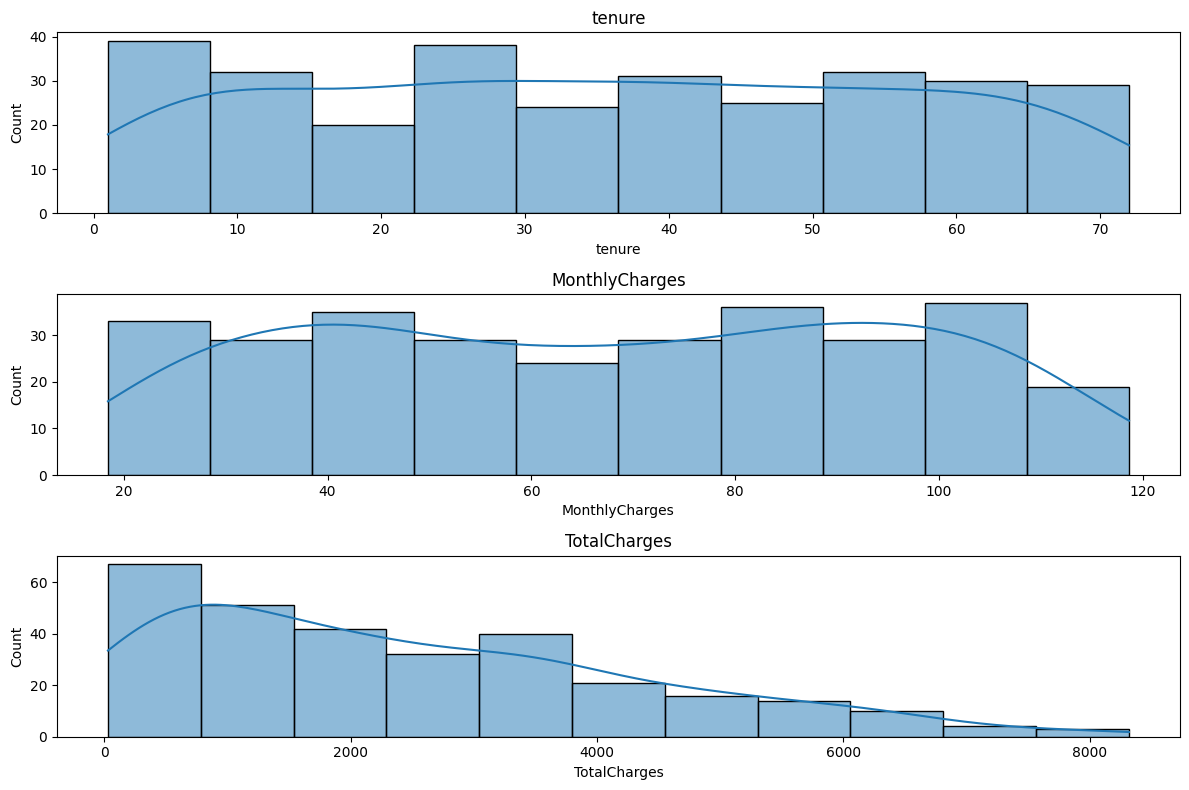

In [195]:
num_cols=[col for col in df.select_dtypes(include=['int','float']) if col!='SeniorCitizen']
fig,axes=plt.subplots(3,1,figsize=(12,8))
for ax,col in zip(axes.flatten(),num_cols):
    sns.histplot(df[col],ax=ax,kde=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Tenure and monthly charges are spread across a wide range, showing that the dataset includes customers at different stages and with different pricing plans. Total charges are right-skewed, which is expected since they accumulate over time, and they largely depend on tenure and monthly charges, making them potentially redundant for modeling

Target Variable Analysis

In [199]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     161
Yes    139
Name: count, dtype: int64
Churn
No     0.536667
Yes    0.463333
Name: proportion, dtype: float64


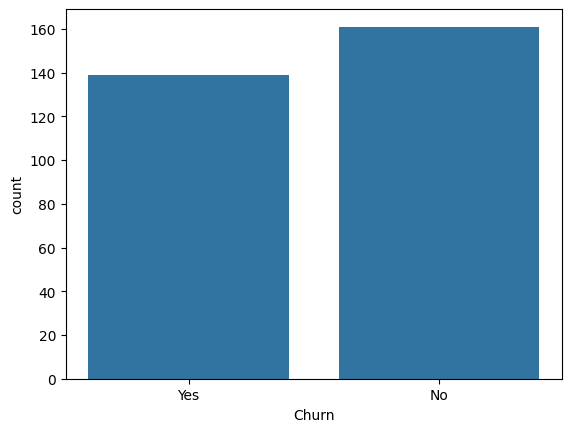

In [203]:
sns.countplot(x='Churn',data=df)
plt.plot()
plt.show()

In [209]:
df['Churnflag']=(df['Churn']=='Yes').astype(int)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churnflag
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes,1
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes,1
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes,1
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No,0
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes,1


Checking churn rate

In [271]:
def churn_by_category(df,col,target="Churnflag"):
    return df.groupby(col).agg(churn_rate=('Churnflag','mean'),customer=('Churnflag','size')).sort_values('churn_rate',ascending=False)

In [272]:
print(churn_by_category(df,'gender'))
print(churn_by_category(df,'Contract'))
print(churn_by_category(df,'SeniorCitizen'))
print(churn_by_category(df,'PaperlessBilling'))
print(churn_by_category(df,'InternetService'))
print(churn_by_category(df,'PaymentMethod'))



        churn_rate  customer
gender                      
Male      0.463576       151
Female    0.463087       149
                churn_rate  customer
Contract                            
Month-to-month    0.486486       111
One year          0.463918        97
Two year          0.434783        92
               churn_rate  customer
SeniorCitizen                      
0                0.496350       137
1                0.435583       163
                  churn_rate  customer
PaperlessBilling                      
No                  0.477941       136
Yes                 0.451220       164
                 churn_rate  customer
InternetService                      
Fiber optic        0.495238       105
DSL                0.447917        96
No                 0.444444        99
                  churn_rate  customer
PaymentMethod                         
Credit card         0.527027        74
Bank transfer       0.500000        76
Electronic check    0.441558        77
Mailed check  

Analysing churn rate based on tenure

In [249]:
df['tenure_bucket']=pd.cut(df['tenure'],bins=[0,6,12,24,48,df['tenure'].max()],labels=['0-6','6-12','12-24','24-48','49+'],include_lowest=True)


In [256]:
df.groupby('tenure_bucket').agg(churn_rate=('Churnflag','mean'),customers=('Churnflag','size')).sort_values('churn_rate',ascending=False)

C:\Users\bhara\AppData\Local\Temp\ipykernel_3960\3826751972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_bucket').agg(churn_rate=('Churnflag','mean'),customers=('Churnflag','size')).sort_values('churn_rate',ascending=False)


,churn_rate,customers
tenure_bucket,,
12-24,0.577778,45
0-6,0.531250,32
6-12,0.521739,23
49+,0.464646,99
24-48,0.376238,101


Churn risk varies across the customer lifecycle, peaking in the first two years and declining significantly for customers with 24–48 months of tenure. Churn increases again for very long-tenured customers, suggesting the need for both early-stage onboarding interventions and late-stage re-engagement strategies

In [267]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     69.243478
Yes    64.890935
Name: MonthlyCharges, dtype: float64

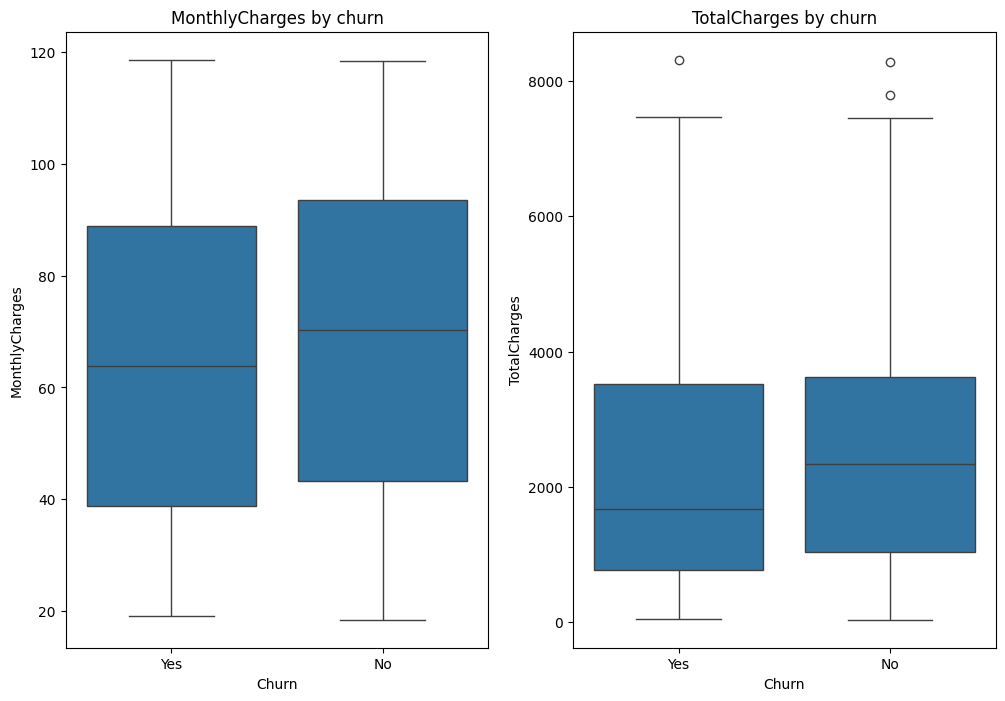

In [264]:
num_col=['MonthlyCharges','TotalCharges']
fig,axes=plt.subplots(1,2,figsize=(12,8))
for ax,col in zip(axes.flatten(),num_col):
    sns.boxplot(data=df,x='Churn',y=col,ax=ax)
    ax.set_title(f"{col} by churn")
plt.show()


Customers who churn tend to have lower monthly charges and significantly lower total charges compared to retained customers. The difference in total charges primarily reflects shorter customer tenure among churners, indicating that total charges may be redundant when tenure is included in the model.

In [273]:
churn_by_category(df, 'TechSupport')


,churn_rate,customer
TechSupport,,
No,0.515789,95
No internet service,0.456311,103
Yes,0.421569,102


Customers without technical support have the highest churn rate, while customers with technical support have the lowest churn rate.

Dataset Overview

The dataset consists of 300 customer records with demographic information, service usage details, contract attributes, and billing-related variables. The target variable Churn indicates whether a customer has discontinued the service.

No missing values were observed, and identifier columns such as customerID were excluded from analysis and modeling.

-> Target Variable Distribution

The churn rate is moderately balanced, with approximately 46% churned customers and 54% retained customers. This indicates that standard classification models can be applied without requiring heavy resampling techniques.

-> Categorical Feature Analysis

Normalized value counts show that most categorical features are well distributed, with no extreme class imbalance or rare categories.

Key findings from churn rate analysis across categorical features:

Contract Type is a strong churn driver:

Month-to-month customers exhibit the highest churn

Two-year contract customers show the lowest churn

InternetService impacts churn:

Fiber optic users churn more than DSL and non-internet customers

PaymentMethod shows variation:

Manual payment methods tend to have lower churn than automatic payments in this dataset

TechSupport is highly influential:

Customers without tech support show the highest churn

Customers with tech support are more likely to stay

Gender shows nearly identical churn rates and appears to be a weak predictor

Customer counts were considered alongside churn rates to ensure reliability of observed patterns.

-> Numeric Feature Analysis

Numeric distributions indicate:

Tenure spans a wide range, representing customers at different lifecycle stages

MonthlyCharges are evenly spread across pricing tiers

TotalCharges show strong right skewness, reflecting cumulative billing behavior

Boxplot analysis reveals:

Churned customers tend to have lower MonthlyCharges

Churned customers have significantly lower TotalCharges, primarily due to shorter tenure

This suggests that TotalCharges largely acts as a proxy for tenure and may be redundant when tenure is included in modeling.

-> Tenure-Based Churn Analysis

Tenure was grouped into lifecycle-based buckets to reduce noise from raw tenure values.

Key observations:

Highest churn occurs within the first 24 months, especially between 12–24 months

Customers with 24–48 months tenure exhibit the lowest churn

Churn increases slightly again for very long-tenured customers (49+ months)

This highlights critical early and mid-lifecycle churn risk periods.

-> Key EDA Insights

Churn is strongly influenced by contract commitment, customer tenure, and service support availability

Early-stage and mid-lifecycle customers are at the highest churn risk

Add-on services (especially TechSupport) increase customer stickiness

Pricing alone does not fully explain churn; lifecycle and engagement factors are more influential

-> EDA Conclusion

The analysis identifies tenure, contract type, InternetService, MonthlyCharges, and TechSupport as the most promising predictors of churn.
Based on these insights, the dataset is well-suited for feature engineering and predictive modeling.